# Handwritten Digit Recognition

## 1. Project Idea

**Project idea:** Build a computer vision system that recognizes handwritten digits from 0 to 9.

**Application domain:** Document and form automation.

The system receives an image of a handwritten digit and predicts the digit class (0–9). The project uses the public `load_digits` dataset from scikit-learn and a Convolutional Neural Network (CNN).

## 2. Problem Definition

**Problem:** Handwritten digits may appear in forms, records, or scanned documents and need to be converted into digital values.

**Purpose:** Develop a computer vision system that automatically classifies a handwritten digit image.

**Expected output:** One predicted class from 0 to 9 for each input image.

## 3. Computer Vision Implementation

This project uses the **classification** task. The complete pipeline is:

`Input image → preprocessing → CNN → predicted digit`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
digits = load_digits()

X = digits.images.astype(np.float32)
y = digits.target.astype(np.int64)

print("Number of images:", len(X))
print("Image shape:", X[0].shape)
print("Classes:", np.unique(y))

Number of images: 1797
Image shape: (8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


## 4. Data & Model

**Dataset:** scikit-learn Digits dataset.

- 1,797 grayscale images.
- Each image is 8 × 8 pixels.
- 10 classes: digits 0–9.

**Preprocessing:**

- Pixel values are normalized from the original 0–16 range to 0–1.
- The data is split into training and testing sets using a stratified split.

**Model:** A small CNN with two convolutional blocks followed by fully connected layers.

In [3]:
# Normalize pixel values to 0–1
X = X / 16.0

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Convert arrays to PyTorch tensors
X_train_t = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
X_test_t = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 1437
Testing images: 360


In [4]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = DigitCNN().to(device)
print(model)

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
training_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    training_losses.append(epoch_loss)

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {epoch_loss:.4f}")

torch.save(model.state_dict(), "digit_cnn_model.pth")
print("Model saved as digit_cnn_model.pth")

Epoch 01/20 - Loss: 2.2857


Epoch 05/20 - Loss: 0.7947


Epoch 10/20 - Loss: 0.2567


Epoch 15/20 - Loss: 0.1447


Epoch 20/20 - Loss: 0.0982
Model saved as digit_cnn_model.pth


## 5. Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

The project also shows at least one successful prediction and one failure case.

In [6]:
model.eval()

with torch.no_grad():
    logits = model(X_test_t.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9556
Precision: 0.9563
Recall   : 0.9556
F1-score : 0.9555


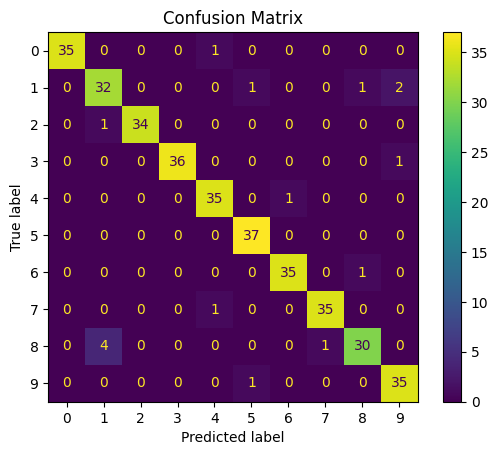

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot()
plt.title("Confusion Matrix")
plt.show()

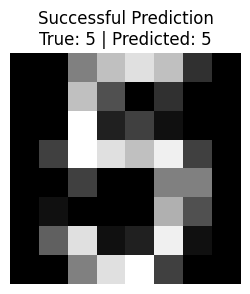

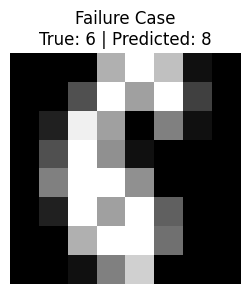

In [8]:
correct_indices = np.where(y_pred == y_test)[0]
wrong_indices = np.where(y_pred != y_test)[0]

success_idx = int(correct_indices[0])
failure_idx = int(wrong_indices[0]) if len(wrong_indices) > 0 else None

plt.figure(figsize=(3, 3))
plt.imshow(X_test[success_idx], cmap="gray")
plt.title(
    f"Successful Prediction\nTrue: {y_test[success_idx]} | Predicted: {y_pred[success_idx]}"
)
plt.axis("off")
plt.show()

if failure_idx is not None:
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test[failure_idx], cmap="gray")
    plt.title(
        f"Failure Case\nTrue: {y_test[failure_idx]} | Predicted: {y_pred[failure_idx]}"
    )
    plt.axis("off")
    plt.show()
else:
    print("No failure case occurred in this run.")

**How the model could be improved:** Use a larger and more diverse handwritten-digit dataset, apply data augmentation, and tune the CNN architecture and training hyperparameters.

## 6. Deployment / Optimization

A real application can call the trained model through a prediction function. For example, a form-processing system could crop a handwritten digit from a scanned form, apply the same preprocessing, and pass it to the model.

In [9]:
def predict_digit(image_8x8):
    image = np.asarray(image_8x8, dtype=np.float32)

    # Accept either original 0–16 data or already-normalized 0–1 data
    if image.max() > 1.0:
        image = image / 16.0

    tensor = torch.tensor(
        image[None, None, :, :],
        dtype=torch.float32
    ).to(device)

    model.eval()
    with torch.no_grad():
        prediction = model(tensor).argmax(dim=1).item()

    return prediction

demo_prediction = predict_digit(X_test[0])
print("Real-application prediction:", demo_prediction)
print("True label:", int(y_test[0]))

Real-application prediction: 5
True label: 5


## 7. Final Submission

The project submission contains:

- `handwritten_digit_recognition.ipynb` — project code/notebook.
- `WORKFLOW.md` — workflow/system diagram.
- `README.md` — required project documentation.

The repository should be uploaded to GitHub and its link submitted through the required form.